In [12]:
import numpy as np


x = np.random.random((200))
np.quantile(x, np.linspace(0, 1, num=7, endpoint=True))

array([6.55387638e-04, 1.98180518e-01, 3.92232753e-01, 4.79443149e-01,
       6.10249409e-01, 8.32295833e-01, 9.97490370e-01])

In [16]:
def f(*a):
    print(a)

f(*{"a": 1, "c": 2, "b": 3})

('a', 'c', 'b')


In [15]:
np.linspace(0, 1, num=7, endpoint=True)

array([0.        , 0.16666667, 0.33333333, 0.5       , 0.66666667,
       0.83333333, 1.        ])

In [ ]:
import pandas as pd
import numpy as np
import math

import statsmodels.api as sm

df = pd.read_csv("./nmi_optimize_4h.csv") #.rename(columns={"value", "nmi"})
df = df.rename(columns={"value": "nmi"})
df['logit_nmi'] = np.log(df['nmi'] / (1 - df['nmi']))

df["b"] = df["b"].astype(int)
df["c"] = df["c"].astype(int)
df["d"] = df["d"].astype(int)

for idx, row in df.iterrows():

    div = math.gcd(int(row["b"]), int(row["c"]), int(row["d"]))

    df.loc[idx, "b"] //= div
    df.loc[idx, "c"] //= div
    df.loc[idx, "d"] //= div

    if div > 1:
        print(div)

2
2
2
4
3
2
2
2
2
2
3
2


In [66]:
df.shape[0] * 10

750

<Axes: ylabel='Density'>

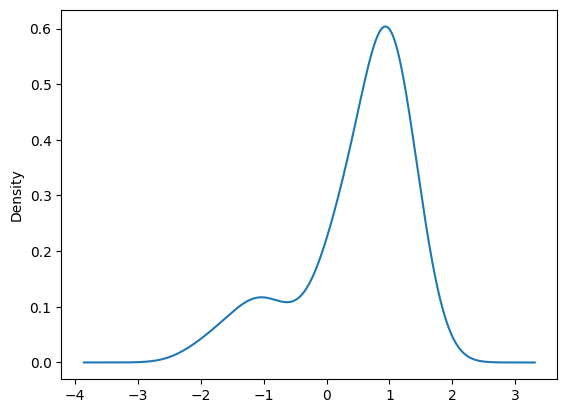

In [52]:
df["logit_nmi"].plot.density()

In [60]:
y = df['logit_nmi']

# Independent variables
X = df[['b', 'c', 'd', 'network_width', 'layer_times_step', 'load_lambda']]

# Add constant for intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

# Display the summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              logit_nmi   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     62.96
Date:                Thu, 10 Apr 2025   Prob (F-statistic):           7.87e-26
Time:                        18:10:38   Log-Likelihood:                -24.023
No. Observations:                  75   AIC:                             62.05
Df Residuals:                      68   BIC:                             78.27
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.5816      0.257  

In [64]:
df.iloc[df["nmi"].argmax()]

trial               69.000000
nmi                  0.820183
b                    1.000000
c                    3.000000
d                    2.000000
load_lambda          0.746461
layer_times_step     1.000000
network_width       80.000000
logit_nmi            1.517585
Name: 69, dtype: float64

NameError: name 'df' is not defined

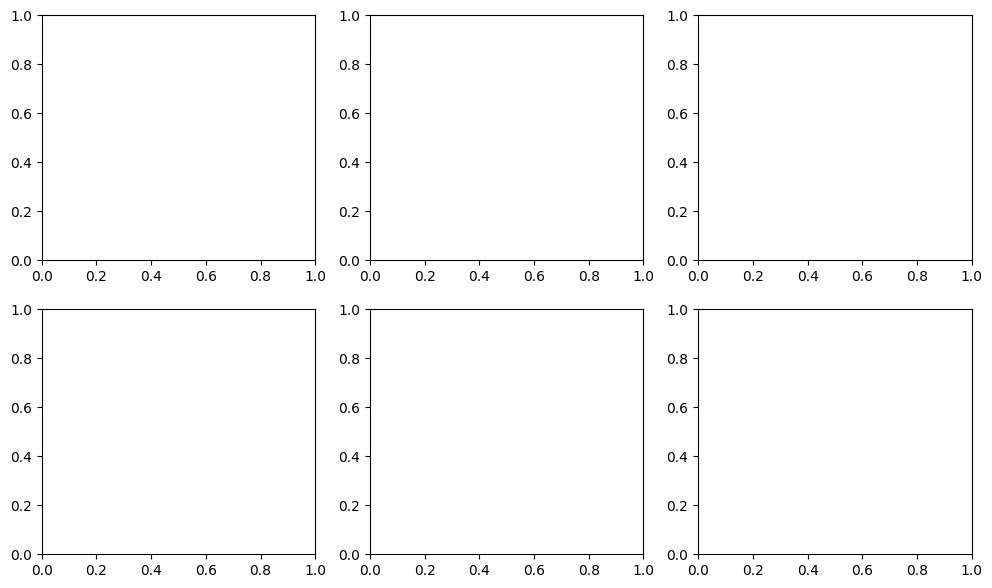

In [ ]:
from matplotlib import pyplot as plt

DV = "logit_nmi"
IV = ['b', 'c', 'd', 'network_width', 'layer_times_step', 'load_lambda']

fig, axs = plt.subplots(2, 3, figsize=(12, 7))

for ax, iv in zip(axs.ravel(), IV):
    df.plot.scatter(iv, DV, ax=ax)

    # p-value
    p_val = model.pvalues[iv]

    # Regression line
    x_vals = df[iv]
    x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
    y_fit = model.params['const'] + model.params[iv] * x_fit
    color = "black" if p_val > 0.05 else "red"
    ax.plot(x_fit, y_fit, '--', color=color)  # dashed line

    ax.set_title(f"p = {p_val:.4f}")

fig.tight_layout()
fig.savefig("./figures/exp_nmi_statistical.pdf")

In [ ]:
fig.